In [ ]:
pip install gensim matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.1 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")

from gensim.models import Word2Vec, FastText
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Kütüphaneler yüklendi!")

✅ Kütüphaneler yüklendi!


In [ ]:
# Küçük bir örnek corpus
sentences =[

    ["veritabanı", "sql", "veri", "kayıt", "backend"],
    ["telefon", "mobil", "uygulama", "ekran", "akıllı"],
    # Yazılım dilleri grubu (yazılım, dil, programlama ortak paydası)
    ["python", "yazılım", "programlama", "dil", "kod"],
    ["java", "yazılım", "programlama", "dil", "kod"],
    ["c++", "yazılım", "programlama", "dil", "kod"],
    ["python", "java", "yazılım", "geliştirme"],
    ["java", "kurumsal", "sistem", "yazılım"],
    ["python", "betik", "yazılım", "hızlı"],

    # Yapay Zeka ve Veri (Python ile ilişkiyi güçlendiriyoruz)
    ["python", "yapay", "zeka", "öğrenme", "veri"],
    ["python", "makine", "öğrenmesi", "veri", "analizi"],
    ["yapay", "zeka", "gelecek", "teknoloji", "veri"],
    ["veri", "bilimi", "python", "istatistik"],
    ["yapay", "zeka", "python", "algoritma"],

    # Web Geliştirme (Javascript odaklı)
    ["javascript", "web", "arayüz", "frontend", "yazılım"],
    ["javascript", "react", "frontend", "web", "kod"],
    ["html", "css", "javascript", "web", "tasarım"],
    ["frontend", "web", "geliştirme", "arayüz"],
    ["web", "tarayıcı", "javascript", "internet"],

    # Donanım grubu (birbirleriyle yoğun etkileşim)
    ["bilgisayar", "donanım", "işlemci", "ram", "hızlı"],
    ["bilgisayar", "ekran", "klavye", "donanım", "parça"],
    ["işlemci", "ram", "anakart", "performans", "donanım"],
    ["ram", "bellek", "hız", "bilgisayar", "donanım"],
    ["donanım", "teknoloji", "bilgisayar", "sistem"]
]


# ── Skip-gram modeli ──
model_sg = Word2Vec(
    sentences,
    vector_size=50,   # vektör boyutu
    window=3,         # komşuluk penceresi
    min_count=1,      # minimum kelime frekansı
    sg=1,             # 1 = Skip-gram, 0 = CBOW
    epochs=200,
    seed=42
)

# ── CBOW modeli ──
model_cbow = Word2Vec(
    sentences,
    vector_size=50,
    window=3,
    min_count=1,
    sg=0,             # CBOW
    epochs=200,
    seed=42
)

print("✅ Modeller eğitildi!")
print(f"Kelime hazinesi boyutu: {len(model_sg.wv)}")
print(f"Vektör boyutu: {model_sg.wv.vector_size}")


✅ Modeller eğitildi!
Kelime hazinesi boyutu: 53
Vektör boyutu: 50


In [ ]:
# Bir kelimenin vektörüne bakalım
kelime = "yazılım"
vektor = model_sg.wv[kelime]
print(f"'{kelime}' kelimesinin vektörü (ilk 10 eleman):")
print(np.round(vektor[:10], 3))
print(f"\nVektör şekli: {vektor.shape}")

# En benzer kelimeler
print("\n--- 'yazılım' kelimesine en benzer kelimeler ---")
benzerler = model_sg.wv.most_similar("yazılım", topn=5)
for kelime, skor in benzerler:
    print(f"  {kelime:15s}  benzerlik: {skor:.4f}")

'yazılım' kelimesinin vektörü (ilk 10 eleman):
[-0.002 -0.004  0.    -0.     0.01  -0.005 -0.027  0.03  -0.051 -0.012]

Vektör şekli: (50,)

--- 'yazılım' kelimesine en benzer kelimeler ---
  veri             benzerlik: 0.8584
  web              benzerlik: 0.8436
  donanım          benzerlik: 0.8401
  python           benzerlik: 0.8397
  javascript       benzerlik: 0.8388


In [ ]:
# 3. Yeni Korpusuna Uygun Kelime Çiftleri
# (Korpusta olmayan kelime hata verir, o yüzden sadece yukarıdaki kelimeleri seçtik)
cifler = [
    ("python", "java"),      # İkisi de yazılım dili
    ("python", "zeka"),      # Aynı cümlede geçiyorlar
    ("bilgisayar", "ram"),   # Donanım ilişkisi
    ("yazılım", "arayüz"),   # Yazılım dünyası ilişkisi
    ("sql", "ekran"),        # Biri veritabanı diğeri donanım (düşük çıkabilir)
    ("python", "internet")   # Uzak kavramlar
]

print("✅ Teknoloji Modeli Eğitildi!")
print(f"Kelime hazinesi boyutu: {len(model_sg.wv)}")
print("-" * 50)
print(f"{'Kelime Çifti':<25} {'Skor':>10}  {'Görsel Grafik'}")
print("-" * 50)

for k1, k2 in cifler:
    if k1 in model_sg.wv and k2 in model_sg.wv:
        skor = model_sg.wv.similarity(k1, k2)
        # Negatif skorları bar grafiğinde göstermemek için 0 ile sınırlayalım
        bar_boyutu = max(0, int(skor * 20))
        bar = "█" * bar_boyutu
        print(f"({k1:10} - {k2:10}) {skor:>8.4f}  {bar}")
    else:
        print(f"Hata: '{k1}' veya '{k2}' kelimesi korpusta bulunamadı!")

✅ Teknoloji Modeli Eğitildi!
Kelime hazinesi boyutu: 53
--------------------------------------------------
Kelime Çifti                    Skor  Görsel Grafik
--------------------------------------------------
(python     - java      )   0.8350  ████████████████
(python     - zeka      )   0.8304  ████████████████
(bilgisayar - ram       )   0.7347  ██████████████
(yazılım    - arayüz    )   0.5643  ███████████
(sql        - ekran     )   0.7310  ██████████████
(python     - internet  )   0.6339  ████████████


In [ ]:
# Kelimeler arası benzerlik skoru
cifler = [
    ("python", "java"),
    ("python", "zeka"),
    ("bilgisayar", "ram"),
    ("yazılım", "arayüz"),
    ("sql", "ekran"),
    ("python", "internet")
]

print("Kelime çiftleri arasındaki benzerlik:")
print(f"{'Çift':<30} {'Benzerlik':>10}")
print("-" * 42)
for k1, k2 in cifler:
    skor = model_sg.wv.similarity(k1, k2)
    bar = "█" * int(skor * 20)
    print(f"({k1}, {k2}){'':<15} {skor:>6.4f}  {bar}")

Kelime çiftleri arasındaki benzerlik:
Çift                            Benzerlik
------------------------------------------
(python, java)                0.8350  ████████████████
(python, zeka)                0.8304  ████████████████
(bilgisayar, ram)                0.7347  ██████████████
(yazılım, arayüz)                0.5643  ███████████
(sql, ekran)                0.7310  ██████████████
(python, internet)                0.6339  ████████████


In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Vektör aritmetiği
print("=== Vektör Aritmetiği ===\n")
# Denklem: Javascript - Frontend + Yapay_Zeka = ?
# Kral - Erkek + Kadın = ?
sonuc = model_sg.wv.most_similar(
    positive=["javascript", "zeka"],  # 'yapay_zeka' yerine 'zeka' kullanıldı
    negative=["frontend"],          # çıkar
    topn=3
)
print("Javascript - Frontend + Yapay_Zeka = ?")
for kelime, skor in sonuc:
    print(f"  → {kelime:15s}  ({skor:.4f})")

print()

=== Vektör Aritmetiği ===

Javascript - Frontend + Yapay_Zeka = ?
  → ekran            (0.7186)
  → bilgisayar       (0.7126)
  → veri             (0.6875)



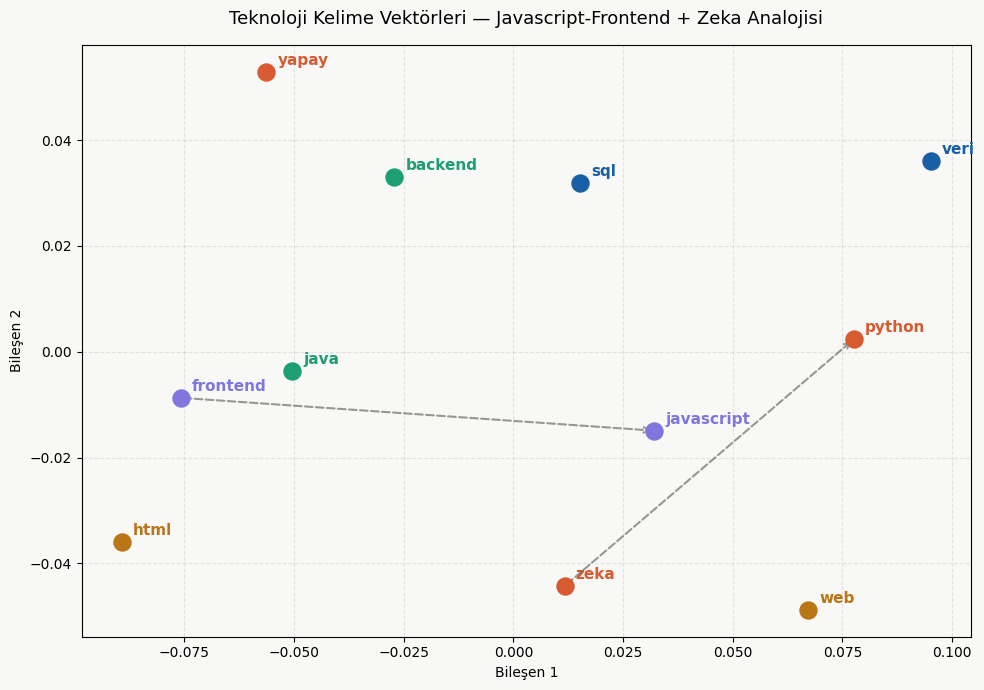

✅ Grafik kaydedildi: teknoloji_vektor_uzayi.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Görselleştirilecek teknoloji kelimeleri
# (Önceki adımda eğittiğimiz model_sg'yi kullandığını varsayıyoruz)
raw_kelimeler = ["javascript", "frontend", "python", "yapay", "zeka",
             "java", "backend", "sql", "veri",
             "html", "web"]

# Sadece modelin kelime hazinesinde bulunan kelimeleri al
kelimeler = [k for k in raw_kelimeler if k in model_sg.wv]

# Vektörleri numpy dizisine çevir
vektorler = np.array([model_sg.wv[k] for k in kelimeler])

# PCA ile 2 boyuta indir
pca = PCA(n_components=2, random_state=42)
vek_2d = pca.fit_transform(vektorler)

# Renk grupları - Teknoloji dünyasına uyarlandı
renkler = {
    "web_dev":  ("#7F77DD", ["javascript", "frontend"]),
    "ai_data":  ("#D85A30", ["python", "yapay", "zeka"]),
    "backend":  ("#1D9E75", ["java", "backend"]),
    "database": ("#185FA5", ["sql", "veri"]),
    "ui_ux":    ("#BA7517", ["html", "web"]),
}

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_facecolor("#f8f8f6")
fig.patch.set_facecolor("#f8f8f6")

for grup, (renk, grup_kelimeleri) in renkler.items():
    for kw in grup_kelimeleri:
        if kw in kelimeler: # Sadece görselleştirilen kelimeler için nokta çiz
            idx = kelimeler.index(kw)
            x, y = vek_2d[idx]
            ax.scatter(x, y, color=renk, s=150, zorder=5)
            ax.annotate(kw, (x, y), textcoords="offset points",
                        xytext=(8, 5), fontsize=11, color=renk, fontweight="bold")

# Analoji okları: (Frontend -> Javascript) ile (Zeka -> Python)
for k1, k2 in [("frontend", "javascript"), ("zeka", "python")]:
    if k1 in kelimeler and k2 in kelimeler:
        i1, i2 = kelimeler.index(k1), kelimeler.index(k2)
        ax.annotate("", xy=vek_2d[i2], xytext=vek_2d[i1],
                    arrowprops=dict(arrowstyle="->", color="#555", lw=1.5, linestyle="dashed", alpha=0.6))
    else:
        print(f"Uyarı: '{k1}' veya '{k2}' analoji okunda bulunamayan bir kelime.")

ax.set_title("Teknoloji Kelime Vektörleri — Javascript-Frontend + Zeka Analojisi", fontsize=13, pad=15)
ax.set_xlabel("Bileşen 1"); ax.set_ylabel("Bileşen 2")
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig("teknoloji_vektor_uzayi.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Grafik kaydedildi: teknoloji_vektor_uzayi.png")